# Austin accident analysis

This notebook mirrors the structure of `dallas_clustering.ipynb`:

1. Severity classification baseline (from `train_austin.py`)
2. Load Austin coordinates → K-Means → rank → elbow → plots → worst-zone report → Folium map
3. Optional: DBSCAN hotspots (defaults from `hotspot_worst_zones.py`)

Run cells in order.


In [1]:
"""
Austin accident analysis — classification + hotspot clustering
==============================================================
- Random Forest severity baseline (train_austin.py logic)
- K-Means hotspot prioritization (same flow as dallas_clustering.ipynb)
- Optional DBSCAN export (hotspot_worst_zones.py defaults)

Requirements:
    pip install pandas numpy scikit-learn matplotlib folium
"""

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN

# Optional map (same as Dallas notebook)
try:
    import folium
except ImportError:
    folium = None


In [2]:
# ── A. Severity classification baseline (train_austin.py) ─────────────────────
DATA_PATH = Path("austin_data.csv")

NUMERIC_FEATURES = [
    "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
    "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)",
    "Distance(mi)", "Start_Lat", "Start_Lng",
]
CATEGORICAL_FEATURES = [
    "Weather_Condition", "Wind_Direction", "Sunrise_Sunset",
    "Civil_Twilight", "Source", "Airport_Code",
]
BOOLEAN_FEATURES = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop",
]


def load_and_engineer(path: Path):
    df = pd.read_csv(path, low_memory=False)
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
    df["month"] = df["Start_Time"].dt.month
    df["hour"] = df["Start_Time"].dt.hour
    df["dayofweek"] = df["Start_Time"].dt.dayofweek
    feature_cols = NUMERIC_FEATURES + ["month", "hour", "dayofweek"] + CATEGORICAL_FEATURES + BOOLEAN_FEATURES
    X = df[feature_cols].copy()
    y = df["Severity"].copy()
    for c in BOOLEAN_FEATURES:
        if X[c].dtype == object:
            X[c] = X[c].map({"True": True, "False": False})
        X[c] = X[c].astype(bool).astype(np.int8)
    for c in CATEGORICAL_FEATURES:
        X[c] = X[c].fillna("missing").astype(str)
    mask = y.notna() & X["month"].notna()
    return X.loc[mask], y.loc[mask]


def build_pipeline():
    numeric_all = NUMERIC_FEATURES + ["month", "hour", "dayofweek"]
    numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, min_frequency=0.001)),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_all),
            ("cat", categorical_transformer, CATEGORICAL_FEATURES),
            ("bool", "passthrough", BOOLEAN_FEATURES),
        ],
        remainder="drop",
    )
    clf = RandomForestClassifier(
        n_estimators=150, max_depth=24, min_samples_leaf=5,
        class_weight="balanced", n_jobs=-1, random_state=42,
    )
    return Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])


def majority_baseline(y_train, y_test):
    mode = y_train.mode().iloc[0]
    pred = np.full(shape=len(y_test), fill_value=mode)
    return accuracy_score(y_test, pred)


X, y = load_and_engineer(DATA_PATH)
print(f"Samples after cleaning: {len(X):,}")
print(y.value_counts().sort_index(), "\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Majority-class baseline (test accuracy): {majority_baseline(y_train, y_test):.4f}\n")

pipe = build_pipeline()
pipe.fit(X_train, y_train)
y_test_pred = pipe.predict(X_test)

print("Test accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Test macro-F1:", round(f1_score(y_test, y_test_pred, average="macro"), 4))
labels = sorted(y.unique())
print("\nConfusion matrix (test):")
print(pd.DataFrame(
    confusion_matrix(y_test, y_test_pred, labels=labels),
    index=[f"true_{i}" for i in labels],
    columns=[f"pred_{i}" for i in labels],
))
print("\n", classification_report(y_test, y_test_pred, labels=labels, digits=4))


Samples after cleaning: 92,024
Severity
1      722
2    82314
3     8584
4      404
Name: count, dtype: int64 

Majority-class baseline (test accuracy): 0.8945

Test accuracy : 0.8673
Test macro-F1: 0.5305

Confusion matrix (test):
        pred_1  pred_2  pred_3  pred_4
true_1     108      35       0       1
true_2     343   14604    1472      44
true_3      21     451    1226      19
true_4       2      43      11      25

               precision    recall  f1-score   support

           1     0.2278    0.7500    0.3495       144
           2     0.9650    0.8871    0.9244     16463
           3     0.4526    0.7140    0.5540      1717
           4     0.2809    0.3086    0.2941        81

    accuracy                         0.8673     18405
   macro avg     0.4816    0.6649    0.5305     18405
weighted avg     0.9085    0.8673    0.8826     18405



In [3]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("austin_data.csv", usecols=["Start_Lat", "Start_Lng", "Severity"])
df = df.rename(columns={"Start_Lat": "latitude", "Start_Lng": "longitude", "Severity": "severity"})
df["severity"] = df["severity"].astype(float)
df = df.dropna(subset=["latitude", "longitude", "severity"]).reset_index(drop=True)

LAT_MIN, LAT_MAX = 29.9, 30.7
LNG_MIN, LNG_MAX = -98.1, -97.4
df = df[
    (df["latitude"] >= LAT_MIN) & (df["latitude"] <= LAT_MAX)
    & (df["longitude"] >= LNG_MIN) & (df["longitude"] <= LNG_MAX)
].reset_index(drop=True)

print(f"Loaded {len(df)} accident records (Austin bounds).\n")


Loaded 96604 accident records (Austin bounds).



In [4]:
# ── 2. Fit K-Means ────────────────────────────────────────────────────────────
os.environ["OMP_NUM_THREADS"] = "1"

coords = df[["latitude", "longitude"]].values
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = km.fit_predict(coords)
cluster_centers = km.cluster_centers_


In [6]:
# ── 3. Rank clusters ──────────────────────────────────────────────────────────
density_weight = 0.60
severity_weight = 0.40

stats = (
    df.groupby("cluster")
    .agg(
        accident_count=("severity", "count"),
        avg_severity=("severity", "mean"),
        max_severity=("severity", "max"),
    )
    .reset_index()
)

stats["centroid_lat"] = stats["cluster"].apply(lambda i: cluster_centers[i, 0])
stats["centroid_lng"] = stats["cluster"].apply(lambda i: cluster_centers[i, 1])

scaler = MinMaxScaler()
stats[["norm_count", "norm_severity"]] = scaler.fit_transform(
    stats[["accident_count", "avg_severity"]]
)
stats["composite_score"] = (
    density_weight * stats["norm_count"] + severity_weight * stats["norm_severity"]
)

stats = stats.sort_values("composite_score", ascending=False).reset_index(drop=True)
labels_pri = ["Critical", "High", "Medium", "Low", "Minimal"]
stats["priority"] = [labels_pri[min(i, len(labels_pri) - 1)] for i in range(len(stats))]
stats["rank"] = range(1, len(stats) + 1)

print("=" * 70)
print("HOTSPOT PRIORITY RANKING (K-Means)")
print("=" * 70)
print(stats[[
    "rank", "priority", "accident_count",
    "avg_severity", "composite_score",
    "centroid_lat", "centroid_lng",
]].to_string(index=False))
print()


HOTSPOT PRIORITY RANKING (K-Means)
 rank priority  accident_count  avg_severity  composite_score  centroid_lat  centroid_lng
    1 Critical           33577      2.100039         0.872356     30.272519    -97.716845
    2     High           28013      2.085782         0.699296     30.376638    -97.696968
    3   Medium           18578      2.143772         0.645651     30.187927    -97.765385
    4      Low            8256      2.010780         0.013635     30.245192    -97.864813
    5  Minimal            8180      2.006724         0.000000     30.427021    -97.807046



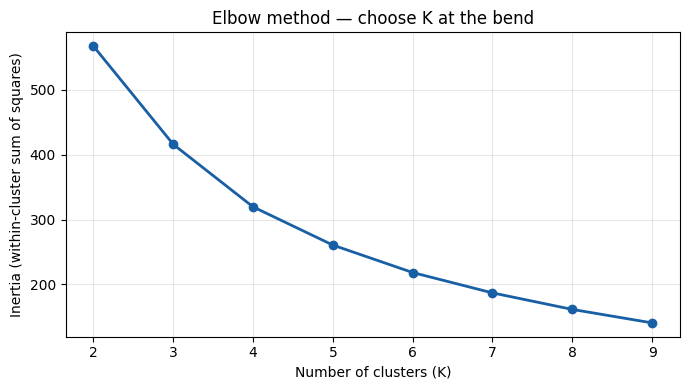

Elbow plot saved → austin_elbow_curve.png


In [7]:
# ── 4. Choose optimal K (elbow method) ───────────────────────────────────────
k_range = range(2, 10)
coords = df[["latitude", "longitude"]].values
inertias = [
    KMeans(n_clusters=k, random_state=42, n_init=10).fit(coords).inertia_
    for k in k_range
]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker="o", linewidth=2, color="#185FA5")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow method — choose K at the bend")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("austin_elbow_curve.png", dpi=150)
plt.show()
print("Elbow plot saved → austin_elbow_curve.png")


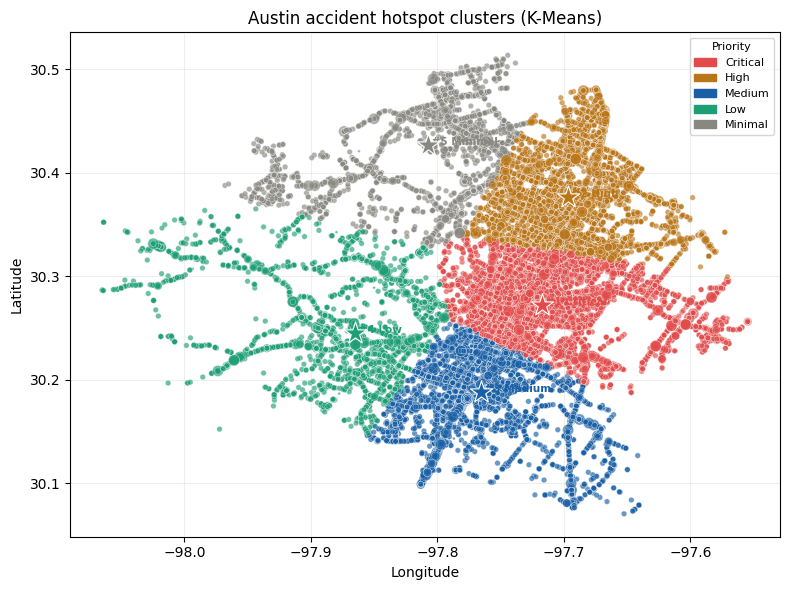

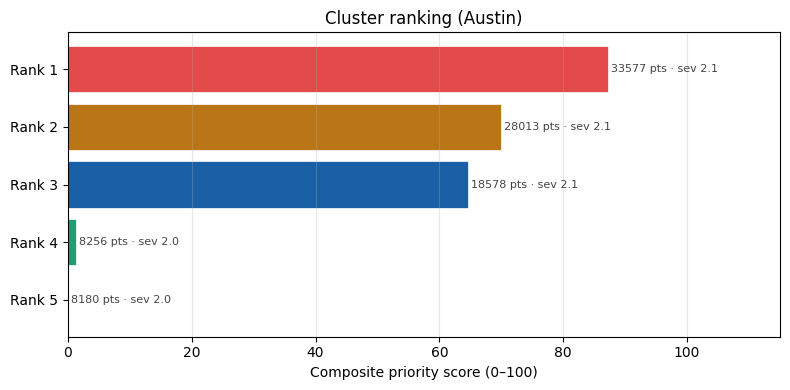

In [8]:
# ── 5a. Spatial scatter ───────────────────────────────────────────────────────
PRIORITY_COLORS = {
    "Critical": "#E24B4A",
    "High":     "#BA7517",
    "Medium":   "#185FA5",
    "Low":      "#1D9E75",
    "Minimal":  "#888780",
}

cluster_color = dict(zip(stats["cluster"], stats["priority"].map(PRIORITY_COLORS)))

fig1, ax = plt.subplots(figsize=(8, 6))
colors = df["cluster"].map(cluster_color)
ax.scatter(
    df["longitude"], df["latitude"],
    c=colors,
    s=df["severity"] ** 2 * 4,
    alpha=0.65,
    linewidths=0.3,
    edgecolors="white",
)
for _, row in stats.iterrows():
    ax.scatter(
        row["centroid_lng"], row["centroid_lat"],
        marker="*", s=280,
        color=PRIORITY_COLORS[row["priority"]],
        edgecolors="white", linewidths=0.8, zorder=5,
    )
    ax.annotate(
        f" #{int(row['rank'])} {row['priority']}",
        (row["centroid_lng"], row["centroid_lat"]),
        fontsize=7.5, fontweight="bold",
        color=PRIORITY_COLORS[row["priority"]],
    )
patches = [mpatches.Patch(color=c, label=p) for p, c in PRIORITY_COLORS.items()
           if p in stats["priority"].values]
ax.legend(handles=patches, title="Priority", fontsize=8, title_fontsize=8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Austin accident hotspot clusters (K-Means)")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("austin_hotspot_scatter.png", dpi=150)
plt.show()

# ── 5b. Ranked bar chart ──────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
bar_colors = stats["priority"].map(PRIORITY_COLORS)
bars = ax2.barh(
    stats["rank"].astype(str).radd("Rank "),
    stats["composite_score"] * 100,
    color=bar_colors, edgecolor="white", linewidth=0.5,
)
for bar, (_, row) in zip(bars, stats.iterrows()):
    ax2.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(row['accident_count'])} pts · sev {row['avg_severity']:.1f}",
        va="center", fontsize=8, color="#444",
    )
ax2.set_xlabel("Composite priority score (0–100)")
ax2.set_title("Cluster ranking (Austin)")
ax2.invert_yaxis()
ax2.grid(True, axis="x", alpha=0.3)
ax2.set_xlim(0, 115)
plt.tight_layout()
plt.savefig("austin_hotspot_ranking.png", dpi=150)
plt.show()


In [9]:
# ── 7. Print worst accident zones ────────────────────────────────────────────

zones = (
    df.groupby("cluster")
    .agg(
        total_accidents=("severity", "count"),
        avg_severity=("severity", "mean"),
        max_severity=("severity", "max"),
        severe_count=("severity", lambda x: (x >= 4.0).sum()),
        centroid_lat=("latitude", "mean"),
        centroid_lng=("longitude", "mean"),
    )
    .reset_index()
)

zones["norm_count"] = zones["total_accidents"] / zones["total_accidents"].max()
zones["norm_severity"] = zones["avg_severity"] / zones["avg_severity"].max()
zones["score"] = 0.6 * zones["norm_count"] + 0.4 * zones["norm_severity"]

zones = zones.sort_values("score", ascending=False).reset_index(drop=True)
zones["rank"] = range(1, len(zones) + 1)

priority_labels = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "MINIMAL"]
zones["priority"] = [priority_labels[min(i, len(priority_labels) - 1)] for i in range(len(zones))]

print()
print("=" * 60)
print("  WORST ACCIDENT ZONES — PRIORITY REPORT (Austin, K-Means)")
print("=" * 60)
print(f"  Total accidents analysed : {len(df)}")
print(f"  Zones identified         : {zones['rank'].max()}")
print("=" * 60)

for _, row in zones.iterrows():
    print()
    print(f"  Rank #{int(row['rank'])}  [{row['priority']}]")
    print("  ----------------------------------------")
    print(f"  Location         : {row['centroid_lat']:.4f}, {row['centroid_lng']:.4f}")
    print(f"  Total accidents  : {int(row['total_accidents'])}")
    print(f"  Avg severity     : {row['avg_severity']:.2f} / 4.0")
    print(f"  Max severity     : {row['max_severity']:.2f} / 4.0")
    print(f"  Severe accidents : {int(row['severe_count'])}  (severity >= 4)")
    print(f"  Priority score   : {row['score']:.2f} / 1.0")

print()
print("=" * 60)
print("  ACTION GUIDE")
print("=" * 60)
print("  CRITICAL / HIGH  -> Immediate intervention required")
print("  MEDIUM           -> Schedule for next fiscal year")
print("  LOW / MINIMAL    -> Monitor; low-cost paint markings")
print("=" * 60)
print()



  WORST ACCIDENT ZONES — PRIORITY REPORT (Austin, K-Means)
  Total accidents analysed : 96604
  Zones identified         : 5

  Rank #1  [CRITICAL]
  ----------------------------------------
  Location         : 30.2725, -97.7168
  Total accidents  : 33577
  Avg severity     : 2.10 / 4.0
  Max severity     : 4.00 / 4.0
  Severe accidents : 143  (severity >= 4)
  Priority score   : 0.99 / 1.0

  Rank #2  [HIGH]
  ----------------------------------------
  Location         : 30.3767, -97.6970
  Total accidents  : 28013
  Avg severity     : 2.09 / 4.0
  Max severity     : 4.00 / 4.0
  Severe accidents : 97  (severity >= 4)
  Priority score   : 0.89 / 1.0

  Rank #3  [MEDIUM]
  ----------------------------------------
  Location         : 30.1879, -97.7654
  Total accidents  : 18578
  Avg severity     : 2.14 / 4.0
  Max severity     : 4.00 / 4.0
  Severe accidents : 82  (severity >= 4)
  Priority score   : 0.73 / 1.0

  Rank #4  [LOW]
  ----------------------------------------
  Location 

In [11]:
# ── 8. Interactive cluster map (Folium) ───────────────────────────────────────
# pip install folium

if folium is None:
    print("Install folium to render the map: pip install folium")
else:
    PRIORITY_COLORS = {
        "CRITICAL": "#E24B4A",
        "HIGH":     "#BA7517",
        "MEDIUM":   "#185FA5",
        "LOW":      "#1D9E75",
        "MINIMAL":  "#888780",
    }
    cluster_to_priority = dict(zip(zones["cluster"], zones["priority"]))
    cluster_to_color = {k: PRIORITY_COLORS[v] for k, v in cluster_to_priority.items()}

    m = folium.Map(
        location=[df["latitude"].mean(), df["longitude"].mean()],
        zoom_start=11,
        tiles="CartoDB positron",
    )

    SAMPLE_SIZE = min(5000, len(df))
    sample = df.sample(SAMPLE_SIZE, random_state=42)

    for _, row in sample.iterrows():
        color = cluster_to_color.get(row["cluster"], "#888")
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=3 + row["severity"] * 0.8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.55,
            weight=0.4,
        ).add_to(m)

    for _, row in stats.iterrows():
        pr = zones.loc[zones["cluster"] == row["cluster"], "priority"].iloc[0]
        folium.Marker(
            location=[row["centroid_lat"], row["centroid_lng"]],
            icon=folium.Icon(color="red", icon="star"),
            popup=f"Rank {int(row['rank'])} {pr}",
        ).add_to(m)

    out = Path("austin_cluster_map.html")
    m.save(out)
    print(f"Saved map → {out}")


Install folium to render the map: pip install folium


### DBSCAN export (`hotspot_worst_zones.py` defaults)

Same parameters as the script: `min_severity=1`, `eps_km=0.15`, `min_samples=5`. Writes `austin_hotspots.csv`.


In [12]:
# ── 9. DBSCAN hotspots (optional; matches hotspot_worst_zones.py) ─────────────
EARTH_RADIUS_KM = 6371.0088

hot = pd.read_csv("austin_data.csv", usecols=["Severity", "Start_Lat", "Start_Lng"], low_memory=False)
hot = hot.dropna(subset=["Severity", "Start_Lat", "Start_Lng"])
hot = hot[(hot["Start_Lat"] != 0) & (hot["Start_Lng"] != 0)]
hot["Severity"] = hot["Severity"].astype(int)
hot = hot[hot["Severity"] >= 1]
hot = hot[
    (hot["Start_Lat"] >= LAT_MIN) & (hot["Start_Lat"] <= LAT_MAX)
    & (hot["Start_Lng"] >= LNG_MIN) & (hot["Start_Lng"] <= LNG_MAX)
].copy()

coords_rad = np.radians(hot[["Start_Lat", "Start_Lng"]].to_numpy())
eps_km = 0.15
min_samples = 5
model = DBSCAN(
    eps=eps_km / EARTH_RADIUS_KM,
    min_samples=min_samples,
    metric="haversine",
    algorithm="ball_tree",
)
hot["cluster_id"] = model.fit_predict(coords_rad)

cl = hot[hot["cluster_id"] != -1].copy()
summary = (
    cl.groupby("cluster_id", as_index=False)
    .agg(
        accident_count=("Severity", "size"),
        avg_severity=("Severity", "mean"),
        max_severity=("Severity", "max"),
        center_lat=("Start_Lat", "mean"),
        center_lng=("Start_Lng", "mean"),
        lat_min=("Start_Lat", "min"),
        lat_max=("Start_Lat", "max"),
        lng_min=("Start_Lng", "min"),
        lng_max=("Start_Lng", "max"),
    )
    .sort_values(["accident_count", "avg_severity"], ascending=[False, False])
    .reset_index(drop=True)
)
summary.insert(0, "zone_rank", range(1, len(summary) + 1))
summary["avg_severity"] = summary["avg_severity"].round(3)

summary.to_csv("austin_hotspots.csv", index=False)
print(f"Rows clustered: {len(hot):,} | Noise: {(hot['cluster_id'] == -1).sum():,}")
print(f"Saved → austin_hotspots.csv ({len(summary)} zones)")
summary.head(10)


Rows clustered: 96,604 | Noise: 4,770
Saved → austin_hotspots.csv (1148 zones)


,zone_rank,cluster_id,accident_count,avg_severity,max_severity,center_lat,center_lng,lat_min,lat_max,lng_min,lng_max
0,1,0,45770,2.168,4,30.292617,-97.733455,30.151243,30.423010,-97.829397,-97.656501
1,2,11,1929,2.010,4,30.446918,-97.782371,30.423800,30.476250,-97.807678,-97.750031
2,3,54,1658,2.011,4,30.236115,-97.687753,30.216760,30.260588,-97.699749,-97.671181
3,4,5,1122,1.998,3,30.307053,-97.739592,30.296597,30.323690,-97.748917,-97.723671
4,5,60,1012,2.007,4,30.327900,-97.725331,30.312382,30.340080,-97.736636,-97.715279
5,6,49,807,2.005,4,30.387408,-97.648846,30.383375,30.392548,-97.652521,-97.643972
6,7,70,789,2.014,4,30.234606,-97.824351,30.229424,30.239307,-97.848076,-97.805199
7,8,44,762,2.157,4,30.423456,-97.671777,30.416048,30.431638,-97.684038,-97.660464
8,9,8,738,2.016,4,30.234726,-97.865587,30.232063,30.240715,-97.880867,-97.850218
9,10,33,710,2.001,4,30.218343,-97.833965,30.208529,30.232098,-97.846413,-97.826477
